# 04 - Método da bisseção
Vamos aprender sobre como usar o método da bisseção para encontrar as raízes de funções reais.

Crie uma nova branch (versão) do repositório:

```bash
git branch semana4
```

Faça o checkout nessa nova branch:

```bash
git checkout semana4
```

A partir desta atividade, os arquivos de algoritmos ficarão dentro da pasta utils.

```txt
├─ utils/
│   └─ __init__.py
│   └─ algoritmos.py
```

<hr />

## Atividade 1
Escreva o método da bisseção dentro do arquivo $utils/algoritmos.py$.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from utils.algoritmos import bissecao


def f(x):
    return x**3 - x - 2


raiz, iteracoes = bissecao(f, 1, 2, tol=1e-15)
print(f"raiz = {raiz:.15f}")
print(f"f(raiz) = {f(raiz):.3e}")
print(f"iterações = {iteracoes}")


raiz = 1.521379706804567
f(raiz) = -1.332e-15
iterações = 50


Importe e teste a função:  

$$
f(x) = x^3 - x - 2
$$

Em que os valores iniciais a e b são obtidos graficamente.

In [2]:
%pip install numpy matplotlib


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


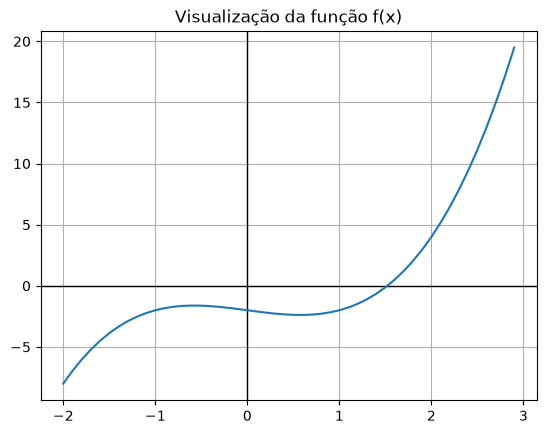

raiz = 1.5213797068045674 , i = 50


In [3]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os

# Sobe um nível para a raiz do projeto e adiciona ao caminho do sistema
sys.path.append(os.path.abspath(os.path.join('..')))

# Agora você importa suas ferramentas da pasta utils
from utils.algoritmos import bissecao

# Definição da função
def f(x):
    return x**3 - x - 2

def plot(f, number=1):
    # Intervalo para plotar
    x_vals = np.arange(-2, 3, 0.1)
    y_vals = f(x_vals)

    plt.axhline(0, color="black", linewidth=1)  # eixo x
    plt.axvline(0, color="black", linewidth=1)  # eixo y
    plt.plot(x_vals, y_vals)
    plt.grid(True)
    plt.title("Visualização da função f(x)")
    plt.show()
    plt.close()

def main():
    plot(f, 1)
    r, i = bissecao(f, 1, 2, 1e-15)
    print(f"raiz = {r} , i = {i}")

if __name__ == "__main__":
    main()

## Atividade 2
Considere a equação  

$$
\sqrt{x} = \cos(x).
$$  

Use o método da bisseção com intervalo inicial obtido por gráfico (entre 0 e 1) para calcular um valor aproximado com precisão de $10^{-4}$ para no máximo 4 iterações.

Após 4 iterações, a aproximação da bisseção é $x=0.65625$. Para atingir precisão de $10^{-4}$, é necessário continuar as iterações; a raiz é aproximadamente:

$$
x \approx 0.6417.
$$


In [4]:
import math
from utils.algoritmos import bissecao


def equacao(x):
    return math.sqrt(x) - math.cos(x)


raiz, iteracoes = bissecao(equacao, 0.0, 1.0, tol=1e-4, max_iter=4)
print(f"raiz aproximada = {raiz:.4f}")
print(f"iterações = {iteracoes}")


raiz aproximada = 0.6562
iterações = 4


## Atividade 3
Trace o gráfico e isole as três primeiras raízes positivas da função:  

$$
f(x) = 5\sin(x^2) - \exp\!\left(\frac{x}{10}\right)
$$  

em intervalos de comprimento $(0.1)$. Então, use o método da bisseção para obter aproximações dos zeros com precisão de $10^{-5}$.  

**Resposta:**  

- Intervalo $(0.4, 0.5)$, zero em $(x \approx 0.45931)$.  
- Intervalo $(1.7, 1.8)$, zero em $(x \approx 1.7036)$.  
- Intervalo $(2.5, 2.6)$, zero em $(x \approx 2.5582)$. 

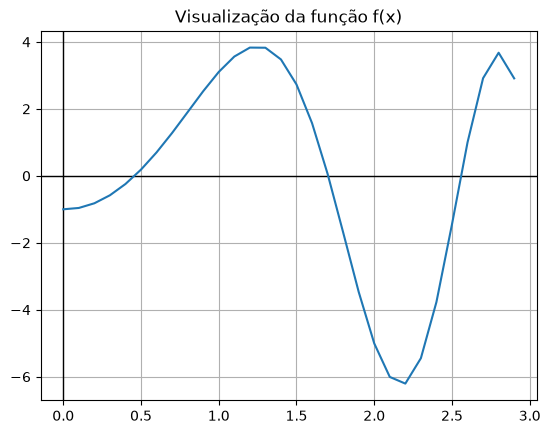

raiz = 0.45931 , i = 14
raiz = 1.7036 , i = 14
raiz = 2.5582 , i = 14


In [5]:
def f3(x):
    return (5 * np.sin(x**2)) - (np.exp(x / 10))

def plot(f, xi, xf, d=0.1):
    # Intervalo para plotar
    x_vals = np.arange(xi, xf, d)
    y_vals = f(x_vals)

    plt.axhline(0, color="black", linewidth=1)  # eixo x
    plt.axvline(0, color="black", linewidth=1)  # eixo y
    plt.plot(x_vals, y_vals)
    plt.grid(True)
    plt.title("Visualização da função f(x)")

    plt.show()
    plt.close()

def main():
    plot(f3, 0, 3)
    r, i = bissecao(f3, 0.4, 0.5, 1e-5)
    print(f"raiz = {r:.5} , i = {i}")
    r, i = bissecao(f3, 1.7, 1.8, 1e-5)
    print(f"raiz = {r:.5} , i = {i}")
    r, i = bissecao(f3, 2.5, 2.6, 1e-5)
    print(f"raiz = {r:.5} , i = {i}")

if __name__ == "__main__":
    main()

## Atividade 4
O desenho abaixo mostra um circuito não linear envolvendo uma fonte de tensão constante, um diodo retificador e um resistor.  

Sabendo que a relação entre a corrente ($I_d$) e a tensão ($v_d$) no diodo é dada pela seguinte expressão:

$ I_d = I_R \left( \exp\left(\tfrac{v_d}{v_t}\right) - 1 \right) $

onde $I_R$ é a corrente de condução reversa e $v_t$ a tensão térmica, dada por  

$ v_t = \tfrac{kT}{q} $

com $k$ a constante de Boltzmann, $T$ a temperatura de operação e $q$ a carga do elétron.  

Aqui, $I_R = 1\,pA = 10^{-12}\,A$, $T = 300\,K$.  

Escreva o problema como uma equação na incógnita $v_d$, usando o método da bisseção, e resolva-o com **3 algarismos significativos** para os seguintes casos:

- $V = 30 \, V$ e $R = 1 \, k\Omega$  
- $V = 3 \, V$ e $R = 1 \, k\Omega$  
- $V = 3 \, V$ e $R = 10 \, k\Omega$  
- $V = 300 \, mV$ e $R = 1 \, k\Omega$  
- $V = -300 \, mV$ e $R = 1 \, k\Omega$  
- $V = -30 \, V$ e $R = 1 \, k\Omega$  
- $V = -30 \, V$ e $R = 10 \, k\Omega$  

![Circuito](https://www.ufrgs.br/reamat/CalculoNumerico/livro-py/main4x.png)

**Dica:**  
A equação do circuito é:

$ V = R I_d + v_d $

**Resposta:**  
a) $0.623$  
b) $0.559$  
c) $0.500$  
d) $0.300$  
e) $-0.300$  
f) $-30$  
g) $-30$

In [6]:
import math
from utils.algoritmos import bissecao


IR = 1e-12
K = 1.380649e-23
TEMPERATURA = 300.0
Q = 1.602176634e-19
VT = K * TEMPERATURA / Q


def corrente_diodo(vd):
    expoente = min(vd / VT, 700.0)
    return IR * math.expm1(expoente)


def tensao_diodo(voltagem, resistencia):
    def circuito(vd):
        return resistencia * corrente_diodo(vd) + vd - voltagem

    if voltagem >= 0:
        intervalo = (0.0, voltagem)
    else:
        intervalo = (voltagem, 0.0)
    return bissecao(circuito, *intervalo, tol=1e-12)[0]


casos = [(30, 1e3), (3, 1e3), (3, 10e3),
         (0.3, 1e3), (-0.3, 1e3), (-30, 1e3), (-30, 10e3)]
for voltagem, resistencia in casos:
    vd = tensao_diodo(voltagem, resistencia)
    print(f"V={voltagem:g} V, R={resistencia:g} ohm -> vd={vd:.3g} V")


V=30 V, R=1000 ohm -> vd=0.623 V
V=3 V, R=1000 ohm -> vd=0.559 V
V=3 V, R=10000 ohm -> vd=0.5 V
V=0.3 V, R=1000 ohm -> vd=0.3 V
V=-0.3 V, R=1000 ohm -> vd=-0.3 V
V=-30 V, R=1000 ohm -> vd=-30 V
V=-30 V, R=10000 ohm -> vd=-30 V


## Atividade 5
Calcule o comprimento do cabo ($C$) entre duas torres de transmissão (i.e., a catenária).  

A distância entre as torres é de $d = 500 \, m$.  

A flecha máxima permitida é $f_{max} = 50 \, m$.  

Flecha é a distância vertical entre uma reta que liga os dois pontos de fixação.  

A flecha ($f$) depende do comprimento do vão ($d$) e da tração ($C$) aplicada ao cabo.  

O seu modelo matemático pode ser:

$ f = C \left[ \cosh\left(\tfrac{d}{2C}\right) - 1 \right] \quad $

**Resposta:** $633.1621 \, m$

In [7]:
import math
from utils.algoritmos import bissecao


def flecha(c, distancia=500.0):
    return c * (math.cosh(distancia / (2 * c)) - 1)


raiz, iteracoes = bissecao(
    lambda c: flecha(c) - 50.0,
    1.0,
    10_000.0,
    tol=1e-8,
)
print(f"comprimento do cabo C = {raiz:.4f} m")
print(f"flecha calculada = {flecha(raiz):.6f} m")
print(f"iterações = {iteracoes}")


comprimento do cabo C = 633.1622 m
flecha calculada = 50.000000 m
iterações = 40


## Atividade 6
Um retificador de meia onda a diodo alimenta uma carga indutiva-resistiva ($f = 1 \, kHz$, $L = 100 \, mH$ e $R = 1 \, k\Omega$).  

Encontre o ângulo $\beta$ para o qual a corrente $I_d$ no diodo se anula.  

Considere o seguinte modelo matemático:

$ I_d = \sin(\beta - \phi) + \sin(\phi)e^{-\tfrac{\beta}{\tan(\phi)}} \quad $

com  

$ \tan(\phi) = \tfrac{2\pi f L}{R} $

**Resposta:** $\beta = 212.2284^\circ$

In [8]:
import math
from utils.algoritmos import bissecao


frequencia = 1_000.0
indutancia = 100e-3
resistencia = 1_000.0
tangente_phi = 2 * math.pi * frequencia * indutancia / resistencia
phi = math.atan(tangente_phi)


def corrente_normalizada(beta):
    return math.sin(beta - phi) + math.sin(phi) * math.exp(-beta / tangente_phi)


beta, iteracoes = bissecao(corrente_normalizada, math.pi, 2 * math.pi, tol=1e-12)
print(f"phi = {math.degrees(phi):.4f} graus")
print(f"beta = {math.degrees(beta):.4f} graus")
print(f"corrente normalizada = {corrente_normalizada(beta):.3e}")
print(f"iterações = {iteracoes}")


phi = 32.1419 graus
beta = 212.2258 graus
corrente normalizada = 6.329e-13
iterações = 42


## Versionando o código

Submeta a branch para o servidor:

```bash
git add .
git commit -m "Semana 4"
git push origin semana4
```